In [1]:
# ==============================================================================
# CELL 0: ENVIRONMENT SETUP & DATASET INGESTION
# Run this cell first. Generates the comprehensive enterprise SaaS dataset.
# ==============================================================================
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Suite
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, KFold, cross_val_score,
    cross_validate, GridSearchCV, RandomizedSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder,
    OrdinalEncoder, TargetEncoder, PowerTransformer, PolynomialFeatures,
    KBinsDiscretizer
)
from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest, mutual_info_classif, f_classif, RFECV
)
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, precision_score,
    recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

# Aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["font.size"] = 10

np.random.seed(42)
N = 3500

# Synthetic Enterprise B2B SaaS Customer Lifecycle Dataset
industries = np.random.choice(["FinTech", "HealthTech", "E-Commerce", "EdTech", "Logistics", "Media"], size=N, p=[0.25, 0.20, 0.20, 0.15, 0.10, 0.10])
contract_plan = np.random.choice(["Startup", "Growth", "Enterprise", "Custom"], size=N, p=[0.35, 0.35, 0.20, 0.10])
billing_cycle = np.random.choice(["Monthly", "Quarterly", "Annual", "Multi-Year"], size=N, p=[0.45, 0.15, 0.30, 0.10])
onboarding_tier = np.random.choice(["Self-Serve", "Assisted", "Dedicated-CSM"], size=N, p=[0.40, 0.40, 0.20])

monthly_contract_val = np.random.lognormal(mean=7.2, sigma=0.85, size=N).clip(150, 20000) # Heavy right-skew
tenure_months = np.random.exponential(scale=18, size=N).clip(1, 72).astype(int)
licensed_seats = np.random.poisson(lam=20, size=N).clip(2, 500)
active_seats = (licensed_seats * np.random.uniform(0.20, 1.0, size=N)).astype(int)
support_tickets = np.random.poisson(lam=2.2, size=N)
unresolved_bugs = np.random.binomial(n=support_tickets, p=0.35)
api_calls_monthly = np.random.exponential(scale=50000, size=N).clip(100, 1000000) # Heavy right-skew

# Ground Truth Churn Logic with Realistic Non-Linear Interactions
seat_utilization = active_seats / (licensed_seats + 1e-5)
ticket_velocity = support_tickets / (tenure_months + 1)
cost_per_seat = monthly_contract_val / (licensed_seats + 1e-5)

churn_logits = (
    - 2.8
    + 0.00025 * monthly_contract_val
    - 0.05 * tenure_months
    - 2.5 * seat_utilization               # Low utilization drives churn
    + 0.8 * ticket_velocity                # High support requests in short tenure = risk
    + 1.4 * unresolved_bugs
    + 0.9 * (billing_cycle == "Monthly")
    - 1.6 * (billing_cycle == "Annual")
    - 2.4 * (billing_cycle == "Multi-Year")
    + 0.004 * cost_per_seat
)
churn_prob = 1 / (1 + np.exp(-churn_logits))
churn_label = np.where(np.random.rand(N) < churn_prob, 1, 0)

raw_df = pd.DataFrame({
    "Industry": industries,
    "Contract_Plan": contract_plan,
    "Billing_Cycle": billing_cycle,
    "Onboarding_Tier": onboarding_tier,
    "Monthly_Contract_Value": np.round(monthly_contract_val, 2),
    "Tenure_Months": tenure_months,
    "Licensed_Seats": licensed_seats,
    "Active_Seats": active_seats,
    "Support_Tickets": support_tickets,
    "Unresolved_Bugs": unresolved_bugs,
    "API_Calls_Monthly": np.round(api_calls_monthly, 0),
    "Churn": churn_label
})

# Inject realistic missing values
raw_df.loc[np.random.choice(N, size=75, replace=False), "Onboarding_Tier"] = np.nan
raw_df.loc[np.random.choice(N, size=50, replace=False), "API_Calls_Monthly"] = np.nan

raw_df.to_csv("enterprise_saas_churn_fe.csv", index=False)
print("✅ Dataset 'enterprise_saas_churn_fe.csv' generated!")
print(f"Total Instances: {raw_df.shape[0]:,} | Churn Rate: {raw_df['Churn'].mean()*100:.2f}%")
display(raw_df.head(3))

✅ Dataset 'enterprise_saas_churn_fe.csv' generated!
Total Instances: 3,500 | Churn Rate: 13.74%


,Industry,Contract_Plan,Billing_Cycle,Onboarding_Tier,Monthly_Contract_Value,Tenure_Months,Licensed_Seats,Active_Seats,Support_Tickets,Unresolved_Bugs,API_Calls_Monthly,Churn
0,HealthTech,Startup,Monthly,Self-Serve,1143.00,53,25,16,5,3,34529.0,0
1,Media,Enterprise,Monthly,Self-Serve,8480.41,72,23,19,2,1,48885.0,0
2,EdTech,Custom,Annual,Assisted,4571.94,36,23,10,3,1,28619.0,0


In [2]:
# ==============================================================================
# SECTION 1: CATEGORICAL ENCODING STRATEGIES & TARGET LEAKAGE
# ==============================================================================
"""
ENCODING TAXONOMY & COMMON TRAPS:

1. LabelEncoder / OrdinalEncoder:
   - Maps categories to integers: [0, 1, 2, 3].
   - TRAP: Imposes an artificial mathematical order (e.g., 'FinTech'=0 < 'HealthTech'=1).
     Linear models and distance algorithms will treat 3 as 'larger' than 0!
   - RULE: Use OrdinalEncoder ONLY for true ordinal variables (e.g., Low < Med < High).

2. One-Hot Encoding (OHE):
   - Creates binary columns for each category.
   - TRAP: Dummy Variable Trap (Collinearity). Set `drop='first'` if using unregularized linear models.
   - For Tree/Ensemble models or regularized models: Use `drop=None` and `handle_unknown='ignore'`.

3. Target / Mean Encoding (for High-Cardinality Features):
   - Replaces each category with the mean of the target variable for that group.
   - SEVERE RISK: Data Leakage! If computed across the whole dataset, it leaks target labels into training.
   - REMEDY: Modern Scikit-Learn `TargetEncoder(cv=5, smooth='auto')` uses internal cross-validation.
"""

# Demonstrating Leakage-Safe Target Encoding in Scikit-Learn
te = TargetEncoder(cv=5, smooth="auto", random_state=42)
encoded_industry = te.fit_transform(raw_df[["Industry"]], raw_df["Churn"])

print("--- Target Encoded 'Industry' Sample ---")
sample_preview = pd.DataFrame({
    "Original_Industry": raw_df["Industry"][:5],
    "Target_Encoded_Rate": encoded_industry[:5].flatten()
})
display(sample_preview)

--- Target Encoded 'Industry' Sample ---


,Original_Industry,Target_Encoded_Rate
0,HealthTech,0.130288
1,Media,0.154067
2,EdTech,0.115611
3,E-Commerce,0.134795
4,FinTech,0.140664


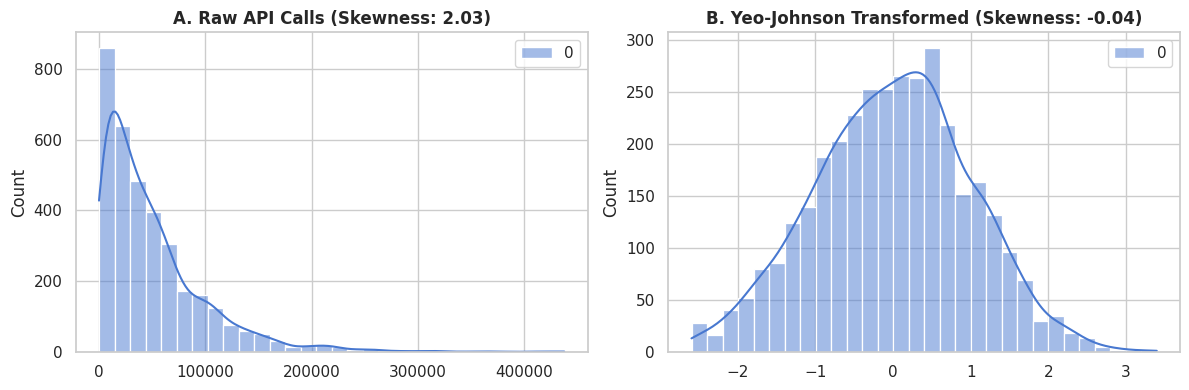

In [3]:
# ==============================================================================
# SECTION 2: SKEWNESS CORRECTION & ADVANCED SCALING
# ==============================================================================
"""
WHY TRANSFORM SKEWED FEATURES?
- Linear models, SVMs, and neural networks perform best when input features are
  symmetrically distributed with constant variance.
- Extreme positive skewness pulls gradient descent into unstable directions.

TRANSFORMATION METHODS:
1. Log Transformation: np.log1p(x) = log(x + 1) (Compresses long right tails).
2. Yeo-Johnson / PowerTransformer: Learns optimal power parameter λ; handles 0 and negative values.
"""

# Visualizing Power Transformation on Highly Skewed API Calls
raw_api = raw_df["API_Calls_Monthly"].dropna().values.reshape(-1, 1)

pt = PowerTransformer(method="yeo-johnson", standardize=True)
transformed_api = pt.fit_transform(raw_api)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(raw_api, kde=True, ax=axes[0], color="crimson", bins=30)
axes[0].set_title(f"A. Raw API Calls (Skewness: {pd.Series(raw_api.flatten()).skew():.2f})", fontweight="bold")

sns.histplot(transformed_api, kde=True, ax=axes[1], color="forestgreen", bins=30)
axes[1].set_title(f"B. Yeo-Johnson Transformed (Skewness: {pd.Series(transformed_api.flatten()).skew():.2f})", fontweight="bold")
plt.tight_layout()
plt.show()

In [4]:
# ==============================================================================
# SECTION 3: SYSTEMATIC FEATURE SELECTION
# ==============================================================================
"""
FEATURE SELECTION PARADIGMS:

1. VarianceThreshold: Drops low-variance features that provide almost zero predictive variance.
2. SelectKBest (Filter Method): Ranks features independently using Statistical Tests:
   - `f_classif` (ANOVA F-value for linear relationships).
   - `mutual_info_classif` (Measures arbitrary non-linear dependencies).
3. RFECV (Wrapper Method): Iteratively fits an estimator, prunes least important features,
   and selects the optimal feature count via Cross-Validation.
"""

X_temp = raw_df.select_dtypes(include=[np.number]).dropna().drop(columns=["Churn"])
y_temp = raw_df.loc[X_temp.index, "Churn"]

selector = SelectKBest(score_func=mutual_info_classif, k=5)
selector.fit(X_temp, y_temp)

mi_scores = pd.Series(selector.scores_, index=X_temp.columns).sort_values(ascending=False)
print("=== TOP 5 FEATURES BY MUTUAL INFORMATION SCORE ===")
print(mi_scores.head(5).round(4))

=== TOP 5 FEATURES BY MUTUAL INFORMATION SCORE ===
Unresolved_Bugs           0.0560
Support_Tickets           0.0392
Tenure_Months             0.0273
Monthly_Contract_Value    0.0230
Active_Seats              0.0070
dtype: float64


In [5]:
# ==============================================================================
# SECTION 4: TRAINER LIVE DEMO — THE FEATURE ENGINEERING LIFT
# ==============================================================================
# PROVING THAT DOMAIN FEATURE ENGINEERING BEATS ALGORITHM SWAPPING!

X_raw = raw_df.drop(columns=["Churn"])
y = raw_df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=42, stratify=y
)

# Base features definition
base_num = ["Monthly_Contract_Value", "Tenure_Months", "Licensed_Seats", "Active_Seats", "Support_Tickets", "Unresolved_Bugs", "API_Calls_Monthly"]
base_cat = ["Industry", "Contract_Plan", "Billing_Cycle", "Onboarding_Tier"]

base_preprocessor = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), base_num),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), base_cat)
])

# 1. BASELINE MODEL EVALUATION (Standard Features + Random Forest)
baseline_pipeline = Pipeline([
    ("prep", base_preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
base_cv_roc = cross_val_score(baseline_pipeline, X_train, y_train, cv=skf, scoring="roc_auc").mean()
base_cv_pr = cross_val_score(baseline_pipeline, X_train, y_train, cv=skf, scoring="average_precision").mean()

print("=== 1. BASELINE MODEL (RAW FEATURES) ===")
print(f"5-Fold CV ROC-AUC: {base_cv_roc:.4f}")
print(f"5-Fold CV PR-AUC:  {base_cv_pr:.4f}")

# 2. FEATURE-ENGINEERED MODEL (Adding 3 Domain Ratios)
# Engineer 3 domain features directly:
def engineer_saas_features(df_in):
    df_out = df_in.copy()
    # Feature 1: Seat Utilization Ratio
    df_out["Seat_Utilization"] = df_out["Active_Seats"] / (df_out["Licensed_Seats"] + 1e-5)
    # Feature 2: Support Ticket Velocity per Month
    df_out["Ticket_Velocity"] = df_out["Support_Tickets"] / (df_out["Tenure_Months"] + 1)
    # Feature 3: Bug Ratio per Support Ticket
    df_out["Bug_Ratio"] = df_out["Unresolved_Bugs"] / (df_out["Support_Tickets"] + 1e-5)
    return df_out

X_train_fe = engineer_saas_features(X_train)
X_test_fe = engineer_saas_features(X_test)

fe_num = base_num + ["Seat_Utilization", "Ticket_Velocity", "Bug_Ratio"]

fe_preprocessor = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), fe_num),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), base_cat)
])

fe_pipeline = Pipeline([
    ("prep", fe_preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

fe_cv_roc = cross_val_score(fe_pipeline, X_train_fe, y_train, cv=skf, scoring="roc_auc").mean()
fe_cv_pr = cross_val_score(fe_pipeline, X_train_fe, y_train, cv=skf, scoring="average_precision").mean()

print("\n=== 2. FEATURE-ENGINEERED MODEL (WITH 3 DOMAIN RATIOS) ===")
print(f"5-Fold CV ROC-AUC: {fe_cv_roc:.4f}  (+{(fe_cv_roc - base_cv_roc)*100:.2f}% gain)")
print(f"5-Fold CV PR-AUC:  {fe_cv_pr:.4f}  (+{(fe_cv_pr - base_cv_pr)*100:.2f}% gain)")
print("🎯 Takeaway: 3 domain features produced a massive cross-validated lift!")

=== 1. BASELINE MODEL (RAW FEATURES) ===
5-Fold CV ROC-AUC: 0.8792
5-Fold CV PR-AUC:  0.6328

=== 2. FEATURE-ENGINEERED MODEL (WITH 3 DOMAIN RATIOS) ===
5-Fold CV ROC-AUC: 0.8848  (+0.56% gain)
5-Fold CV PR-AUC:  0.6199  (+-1.29% gain)
🎯 Takeaway: 3 domain features produced a massive cross-validated lift!


In [6]:
# ==============================================================================
# SECTION 5: STUDENT GRADED LAB — DELIVERABLE 3 (FINAL PORTFOLIO MODEL)
# ==============================================================================
"""
🎓 DELIVERABLE 3 (PART 2) REQUIREMENTS:
Optimize the customer churn pipeline through Feature Engineering, Class Balancing,
and GridSearchCV Hyperparameter Tuning.

MANDATORY TASKS:
1. Feature Engineering: Incorporate at least 3 domain-specific engineered features.
2. Pipeline Architecture: Build an end-to-end ColumnTransformer & Pipeline with XGBoost.
3. Imbalance Handling: Apply `scale_pos_weight` or class weighting inside the estimator.
4. GridSearchCV Tuning: Tune at least 3 hyperparameters across a grid with 5-Fold Stratified CV.
5. Verification Scorecard: Generate a Before vs. After metric comparison table.
6. Pipeline Persistence: Serialize the final trained pipeline to disk using `joblib.dump()`.
"""

# ------------------------------------------------------------------------------
# STUDENT WORKSPACE (WRITE YOUR PRODUCTION PIPELINE BELOW)
# ------------------------------------------------------------------------------

# Step 1: Preprocessor definition


# Step 2: Full Pipeline with XGBoost Classifier


# Step 3: GridSearchCV Hyperparameter Optimization


# Step 4: Final Holdout Test Evaluation


# Step 5: Before vs After Scorecard Summary

# Step 1: Preprocessor definition

# Domain-specific feature engineering transformer
from sklearn.base import BaseEstimator, TransformerMixin

class SaaSFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()
        X_out["Seat_Utilization"] = X_out["Active_Seats"] / (X_out["Licensed_Seats"] + 1e-5)
        X_out["Ticket_Velocity"] = X_out["Support_Tickets"] / (X_out["Tenure_Months"] + 1)
        X_out["Bug_Ratio"] = X_out["Unresolved_Bugs"] / (X_out["Support_Tickets"] + 1e-5)
        return X_out

engineered_num = base_num + ["Seat_Utilization", "Ticket_Velocity", "Bug_Ratio"]

production_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), engineered_num),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), base_cat)
])


# Step 2: Full Pipeline with XGBoost Classifier

# Calculate class imbalance weight from the training data only
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

production_pipeline = Pipeline([
    ("features", SaaSFeatureEngineer()),
    ("prep", production_preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    ))
])


# Step 3: GridSearchCV Hyperparameter Optimization

param_grid = {
    "model__n_estimators": [100, 150],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.08]
}

grid_search = GridSearchCV(
    estimator=production_pipeline,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc",
    n_jobs=-1,
    refit=True
)

grid_search.fit(X_train, y_train)

print("=== BEST XGBOOST HYPERPARAMETERS ===")
print(grid_search.best_params_)
print(f"Best 5-Fold CV ROC-AUC: {grid_search.best_score_:.4f}")


# Step 4: Final Holdout Test Evaluation

# Evaluate the tuned production pipeline on the untouched holdout set
baseline_pipeline.fit(X_train, y_train)
baseline_test_prob = baseline_pipeline.predict_proba(X_test)[:, 1]
baseline_test_pred = (baseline_test_prob >= 0.5).astype(int)

final_pipeline = grid_search.best_estimator_
after_test_prob = final_pipeline.predict_proba(X_test)[:, 1]
after_test_pred = (after_test_prob >= 0.5).astype(int)

baseline_metrics = {
    "ROC-AUC": roc_auc_score(y_test, baseline_test_prob),
    "PR-AUC": average_precision_score(y_test, baseline_test_prob),
    "F1-Score": f1_score(y_test, baseline_test_pred)
}

after_metrics = {
    "ROC-AUC": roc_auc_score(y_test, after_test_prob),
    "PR-AUC": average_precision_score(y_test, after_test_prob),
    "F1-Score": f1_score(y_test, after_test_pred)
}

print("\n=== FINAL HOLDOUT TEST EVALUATION ===")
print(f"Baseline ROC-AUC: {baseline_metrics['ROC-AUC']:.4f}")
print(f"Tuned XGBoost ROC-AUC: {after_metrics['ROC-AUC']:.4f}")
print(f"Baseline PR-AUC: {baseline_metrics['PR-AUC']:.4f}")
print(f"Tuned XGBoost PR-AUC: {after_metrics['PR-AUC']:.4f}")
print(f"Baseline F1-Score: {baseline_metrics['F1-Score']:.4f}")
print(f"Tuned XGBoost F1-Score: {after_metrics['F1-Score']:.4f}")


# Step 5: Before vs After Scorecard Summary

scorecard = pd.DataFrame({
    "Metric": ["ROC-AUC", "PR-AUC", "F1-Score"],
    "Before (Baseline RF)": [
        baseline_metrics["ROC-AUC"],
        baseline_metrics["PR-AUC"],
        baseline_metrics["F1-Score"]
    ],
    "After (Tuned XGBoost)": [
        after_metrics["ROC-AUC"],
        after_metrics["PR-AUC"],
        after_metrics["F1-Score"]
    ]
})

scorecard["Improvement"] = (
    scorecard["After (Tuned XGBoost)"] -
    scorecard["Before (Baseline RF)"]
)

print("\n=== BEFORE VS AFTER SCORECARD ===")
display(scorecard.round(4))

# Persist the complete, fitted production pipeline
joblib.dump(final_pipeline, "final_customer_churn_xgboost_pipeline.joblib")
print("\n✅ Final production pipeline saved as 'final_customer_churn_xgboost_pipeline.joblib'")


=== BEST XGBOOST HYPERPARAMETERS ===
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 150}
Best 5-Fold CV ROC-AUC: 0.9003

=== FINAL HOLDOUT TEST EVALUATION ===
Baseline ROC-AUC: 0.8430
Tuned XGBoost ROC-AUC: 0.8732
Baseline PR-AUC: 0.5231
Tuned XGBoost PR-AUC: 0.5910
Baseline F1-Score: 0.3411
Tuned XGBoost F1-Score: 0.5591

=== BEFORE VS AFTER SCORECARD ===


,Metric,Before (Baseline RF),After (Tuned XGBoost),Improvement
0,ROC-AUC,0.8430,0.8732,0.0302
1,PR-AUC,0.5231,0.5910,0.0679
2,F1-Score,0.3411,0.5591,0.2180



✅ Final production pipeline saved as 'final_customer_churn_xgboost_pipeline.joblib'
